In [2]:
# ==========================================
# 1. INSTALLATION & IMPORTATIONS
# ==========================================
# Dans Kaggle, opencv-python est déjà installé généralement
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import requests

In [3]:
# Configuration du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Exécution sur : {device}")


Exécution sur : cuda


In [4]:
# ==========================================
# 2. CLASSE GRAD-CAM (Logique Identique)
# ==========================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def forward(self, input_image, class_idx=None):
        # A. Passage Avant
        output = self.model(input_image)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
            
        # B. Zero Grad
        self.model.zero_grad()
        
        # C. Rétropropagation
        score = output[0, class_idx]
        score.backward()
        
        # D. Calcul Heatmap
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        cam = np.maximum(cam, 0)
        if np.max(cam) != 0:
            cam = cam / np.max(cam)
            
        return cam, class_idx, score.item()


In [5]:
# ==========================================
# 3. OUTILS VIDEO & PRE-PROCESSING
# ==========================================

def preprocess_frame(frame_bgr):
    """Transforme une frame OpenCV (BGR) en Tensor PyTorch"""
    # Conversion BGR -> RGB
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(frame_rgb)
    
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                             std=[0.229, 0.224, 0.225]),
    ])
    
    tensor = preprocess(pil_img).unsqueeze(0).to(device)
    return pil_img, tensor

def create_heatmap_overlay(original_pil, heatmap):
    """Crée l'overlay visuel"""
    img = np.array(original_pil.resize((224, 224)))
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    
    # Colormap
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    
    # Overlay
    overlay = heatmap_colored * 0.4 + img * 0.6
    overlay = np.uint8(overlay)
    
    # On retourne une image concaténée (Originale | Heatmap | Overlay)
    # Convertir 'img' (RGB) en BGR pour OpenCV si on veut sauver en vidéo
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR) # heatmap_colored est déjà BGR
    
    return np.hstack((img_bgr, overlay_bgr))



In [6]:
# ==========================================
# 4. EXÉCUTION SUR VIDÉO (BOUCLE PRINCIPALE)
# ==========================================
def process_video(video_path, model, grad_cam, max_frames=30):
    cap = cv2.VideoCapture(video_path)
    frames_processed = []
    frame_count = 0
    
    print(f"Traitement de la vidéo : {video_path}")
    
    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
            
        # 1. Prétraitement
        original_pil, input_tensor = preprocess_frame(frame)
        
        # 2. Grad-CAM
        # On force la classe 'Chien' (souvent index entre 151 et 268 dans ImageNet)
        # Ou on laisse le modèle choisir la plus probable
        heatmap, pred_idx, conf = grad_cam.forward(input_tensor)
        
        # 3. Visualisation
        combined_img = create_heatmap_overlay(original_pil, heatmap)
        
        # Ajouter du texte (Classe prédite)
        cv2.putText(combined_img, f"Frame: {frame_count} | Pred: {pred_idx}", 
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        frames_processed.append(combined_img)
        frame_count += 1
        
        if frame_count % 5 == 0:
            print(f"Frame {frame_count} traitée...")
            
    cap.release()
    return frames_processed

def save_video(frames_list, output_name="gradcam_result.mp4"):
    if not frames_list:
        print("Aucune frame à sauvegarder.")
        return
        
    height, width, layers = frames_list[0].shape
    # Codec pour mp4
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
    video = cv2.VideoWriter(output_name, fourcc, 10, (width, height))
    
    for frame in frames_list:
        video.write(frame)
        
    video.release()
    print(f"Vidéo sauvegardée sous : {output_name}")



Traitement de la vidéo : /kaggle/input/videos-test/videos test/dog1.mp4
Frame 5 traitée...
Frame 10 traitée...
Frame 15 traitée...
Frame 20 traitée...
Frame 25 traitée...
Frame 30 traitée...
Frame 35 traitée...
Frame 40 traitée...
Frame 45 traitée...
Frame 50 traitée...
Frame 55 traitée...
Frame 60 traitée...
Vidéo sauvegardée sous : resultat_xai_video.mp4


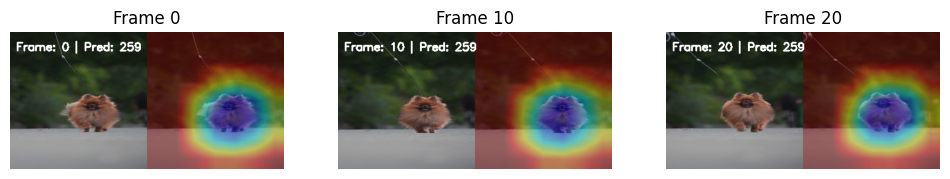

In [7]:
# ==========================================
# 5. MAIN
# ==========================================
if __name__ == "__main__":
    # 1. Modèle
    model = models.resnet50(pretrained=True).to(device)
    target_layer = model.layer4[-1]
    
    # 2. Instance Grad-CAM
    grad_cam = GradCAM(model, target_layer)
    
    # 3. Télécharger vidéo
    video_path = "/kaggle/input/videos-test/videos test/dog1.mp4"
    
    # 4. Traiter X frames (ex: 60 frames = 2 secondes environ)
    result_frames = process_video(video_path, model, grad_cam, max_frames=60)
    
    # 5. Sauvegarder le résultat
    save_video(result_frames, "resultat_xai_video.mp4")
    
    # 6. Afficher quelques résultats statiques dans le notebook pour vérification rapide
    if len(result_frames) > 0:
        plt.figure(figsize=(12, 6))
        # Afficher la 1ère, la 10ème et la 20ème frame
        indices = [0, 10, min(20, len(result_frames)-1)]
        for i, idx in enumerate(indices):
            plt.subplot(1, 3, i+1)
            # Convertir BGR (OpenCV) en RGB (Matplotlib)
            img_rgb = cv2.cvtColor(result_frames[idx], cv2.COLOR_BGR2RGB)
            plt.imshow(img_rgb)
            plt.title(f"Frame {idx}")
            plt.axis('off')
        plt.show()

In [8]:
# ==========================================
# 6. AFFICHAGE DE LA VIDEO DANS LE NOTEBOOK
# ==========================================
from IPython.display import Video, display
import os

def show_video_in_notebook(video_path):
    """
    Convertit la vidéo en H.264 pour compatibilité HTML5 
    et l'affiche dans le notebook.
    """
    output_compatible = "video_web_compatible.mp4"
    
    # Si le fichier existe déjà, on le supprime pour éviter les erreurs
    if os.path.exists(output_compatible):
        os.remove(output_compatible)
        
    print("Conversion de la vidéo pour l'affichage web...")
    # Utilisation de FFMPEG (outil système) pour ré-encoder en H.264
    # -y : écraser si existe, -vcodec libx264 : format web standard
    os.system(f"ffmpeg -y -i {video_path} -vcodec libx264 {output_compatible} -loglevel quiet")
    
    print("Affichage de la vidéo :")
    # Embed=True permet de stocker la vidéo DANS le notebook 
    # (utile si tu télécharges le .ipynb plus tard)
    display(Video(output_compatible, embed=True, width=600, html_attributes="controls loop"))

# Appel de la fonction sur ton résultat
show_video_in_notebook("resultat_xai_video.mp4")

Conversion de la vidéo pour l'affichage web...
Affichage de la vidéo :


Traitement de la vidéo : /kaggle/input/videos-test/videos test/dog2.mp4
Frame 5 traitée...
Frame 10 traitée...
Frame 15 traitée...
Frame 20 traitée...
Frame 25 traitée...
Frame 30 traitée...
Frame 35 traitée...
Frame 40 traitée...
Frame 45 traitée...
Frame 50 traitée...
Frame 55 traitée...
Frame 60 traitée...
Vidéo sauvegardée sous : resultat_xai_video2.mp4


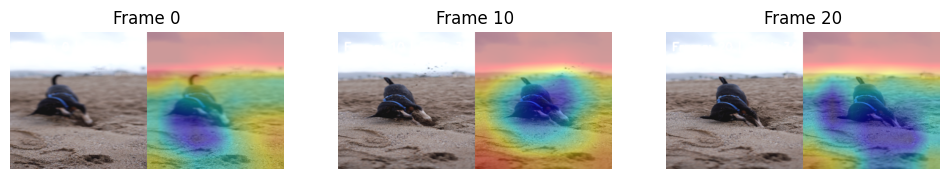

In [9]:
# ==========================================
if __name__ == "__main__":
    # 1. Modèle
    model = models.resnet50(pretrained=True).to(device)
    target_layer = model.layer4[-1]
    
    # 2. Instance Grad-CAM
    grad_cam = GradCAM(model, target_layer)
    
    # 3. Télécharger vidéo
    video_path = "/kaggle/input/videos-test/videos test/dog2.mp4"
    
    # 4. Traiter X frames (ex: 60 frames = 2 secondes environ)
    result_frames = process_video(video_path, model, grad_cam, max_frames=60)
    
    # 5. Sauvegarder le résultat
    save_video(result_frames, "resultat_xai_video2.mp4")
    
    # 6. Afficher quelques résultats statiques dans le notebook pour vérification rapide
    if len(result_frames) > 0:
        plt.figure(figsize=(12, 6))
        # Afficher la 1ère, la 10ème et la 20ème frame
        indices = [0, 10, min(20, len(result_frames)-1)]
        for i, idx in enumerate(indices):
            plt.subplot(1, 3, i+1)
            # Convertir BGR (OpenCV) en RGB (Matplotlib)
            img_rgb = cv2.cvtColor(result_frames[idx], cv2.COLOR_BGR2RGB)
            plt.imshow(img_rgb)
            plt.title(f"Frame {idx}")
            plt.axis('off')
        plt.show()

In [11]:
# Appel de la fonction sur ton résultat
show_video_in_notebook("resultat_xai_video2.mp4")

Conversion de la vidéo pour l'affichage web...
Affichage de la vidéo :


Traitement de la vidéo : /kaggle/input/videos-test/videos test/dog3.mp4
Frame 5 traitée...
Frame 10 traitée...
Frame 15 traitée...
Frame 20 traitée...
Frame 25 traitée...
Frame 30 traitée...
Frame 35 traitée...
Frame 40 traitée...
Frame 45 traitée...
Frame 50 traitée...
Frame 55 traitée...
Frame 60 traitée...
Vidéo sauvegardée sous : resultat_xai_video3.mp4


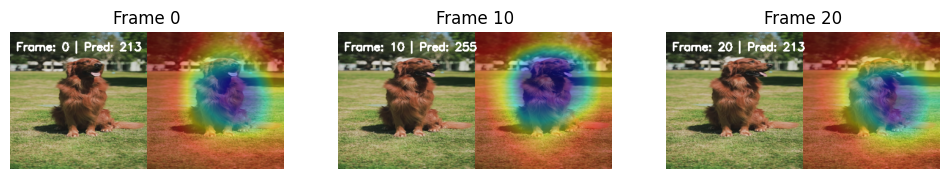

In [12]:
# ==========================================
if __name__ == "__main__":
    # 1. Modèle
    model = models.resnet50(pretrained=True).to(device)
    target_layer = model.layer4[-1]
    
    # 2. Instance Grad-CAM
    grad_cam = GradCAM(model, target_layer)
    
    # 3. Télécharger vidéo
    video_path = "/kaggle/input/videos-test/videos test/dog3.mp4"
    
    # 4. Traiter X frames (ex: 60 frames = 2 secondes environ)
    result_frames = process_video(video_path, model, grad_cam, max_frames=60)
    
    # 5. Sauvegarder le résultat
    save_video(result_frames, "resultat_xai_video3.mp4")
    
    # 6. Afficher quelques résultats statiques dans le notebook pour vérification rapide
    if len(result_frames) > 0:
        plt.figure(figsize=(12, 6))
        # Afficher la 1ère, la 10ème et la 20ème frame
        indices = [0, 10, min(20, len(result_frames)-1)]
        for i, idx in enumerate(indices):
            plt.subplot(1, 3, i+1)
            # Convertir BGR (OpenCV) en RGB (Matplotlib)
            img_rgb = cv2.cvtColor(result_frames[idx], cv2.COLOR_BGR2RGB)
            plt.imshow(img_rgb)
            plt.title(f"Frame {idx}")
            plt.axis('off')
        plt.show()

In [13]:
# Appel de la fonction sur ton résultat
show_video_in_notebook("resultat_xai_video3.mp4")

Conversion de la vidéo pour l'affichage web...
Affichage de la vidéo :


Traitement de la vidéo : /kaggle/input/videos-test/videos test/cat1.mp4
Frame 5 traitée...
Frame 10 traitée...
Frame 15 traitée...
Frame 20 traitée...
Frame 25 traitée...
Frame 30 traitée...
Frame 35 traitée...
Frame 40 traitée...
Frame 45 traitée...
Frame 50 traitée...
Frame 55 traitée...
Frame 60 traitée...
Vidéo sauvegardée sous : resultat_xai_video4.mp4


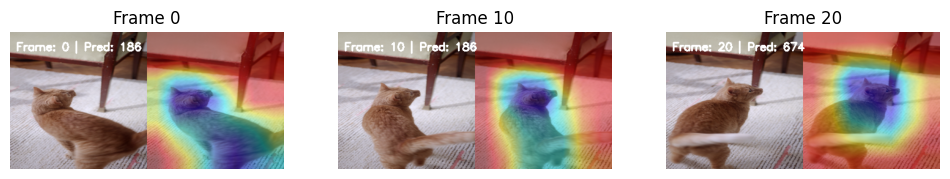

In [14]:
# ==========================================
if __name__ == "__main__":
    # 1. Modèle
    model = models.resnet50(pretrained=True).to(device)
    target_layer = model.layer4[-1]
    
    # 2. Instance Grad-CAM
    grad_cam = GradCAM(model, target_layer)
    
    # 3. Télécharger vidéo
    video_path = "/kaggle/input/videos-test/videos test/cat1.mp4"
    
    # 4. Traiter X frames (ex: 60 frames = 2 secondes environ)
    result_frames = process_video(video_path, model, grad_cam, max_frames=60)
    
    # 5. Sauvegarder le résultat
    save_video(result_frames, "resultat_xai_video4.mp4")
    
    # 6. Afficher quelques résultats statiques dans le notebook pour vérification rapide
    if len(result_frames) > 0:
        plt.figure(figsize=(12, 6))
        # Afficher la 1ère, la 10ème et la 20ème frame
        indices = [0, 10, min(20, len(result_frames)-1)]
        for i, idx in enumerate(indices):
            plt.subplot(1, 3, i+1)
            # Convertir BGR (OpenCV) en RGB (Matplotlib)
            img_rgb = cv2.cvtColor(result_frames[idx], cv2.COLOR_BGR2RGB)
            plt.imshow(img_rgb)
            plt.title(f"Frame {idx}")
            plt.axis('off')
        plt.show()

In [15]:
# Appel de la fonction sur ton résultat
show_video_in_notebook("resultat_xai_video4].mp4")

Conversion de la vidéo pour l'affichage web...
Affichage de la vidéo :
